# 05 — Greeks: bump-and-revalue MC vs off-grid PDE

This notebook reports Δ, Γ, vega and pairwise correlation sensitivity for
the worst-of FCN, computed two ways:

1. **MC, bump-and-revalue with common random numbers (CRN).** Pre-draw a
   single block of standard normals; re-price the FCN with one parameter
   nudged $\pm\epsilon$, reusing the same normals so the only difference
   between the up and down evaluations is the parameter itself. The
   finite-difference signal is the sensitivity; the rest of the sampling
   noise cancels along the path.
2. **PDE, off-grid finite differences.** The 1D Crank–Nicolson grid gives us
   $V(S, t=0)$ across a fan of spot levels; Δ and Γ at $S = S_0$ come from
   a 3-point central difference along that grid. Vega is a small bump-and-
   revalue at the PDE level — no Monte Carlo, no noise.

**Headline plot.** Δ as a function of spot, near the autocall and KI
barriers, with the MC ± 1σ error band overlaid on the PDE reference. This
is the "MC Greeks are noisy near barriers" demonstration that motivates
all the variance-reduction work in Phase 6.

**Reading order**
1. Setup — same JT-spec'd 3-asset FCN as Phase 3.
2. The 3-asset Greeks table (MC only — PDE is single-asset, Phase 4).
3. Single-asset cross-validation: MC vs PDE Greeks should agree well in the
   middle of the distribution; the interesting failure mode is at the
   barriers.
4. Δ-vs-spot scan: MC noise blows up near the KI and AC barriers; the PDE
   stays smooth.
5. Discussion.


In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data, MarketData
from src.fcn_payoff import FCNProduct
from src.mc_pricer import price_fcn
from src.pde_pricer import price_fcn_pde_1d
from src.greeks import mc_greeks_bump, pde_greeks_1d, mc_delta_curve, pde_delta_curve

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.set_printoptions(suppress=True, precision=6)


## 1. Setup — re-use the Phase 3 market snapshot

Same as-of-date AMZN/META/MU basket and JT-spec'd 6-observation FCN.

In [2]:
ISSUE_DATE = date(2025, 10, 17)
TICKERS = ("AMZN", "META", "MU")
market = load_market_data(tickers=TICKERS, lookback_years=5, target_T=0.5, as_of=ISSUE_DATE)
print(market.summary())

product = FCNProduct(
    notional=50_000.0,
    coupon_rate=0.01535,
    obs_dates=(
        date(2025, 12, 1),
        date(2025, 12, 31),
        date(2026, 2, 2),
        date(2026, 3, 2),
        date(2026, 3, 31),
        date(2026, 4, 30),
    ),
    pay_dates=(
        date(2025, 12, 3),
        date(2026, 1, 5),
        date(2026, 2, 4),
        date(2026, 3, 4),
        date(2026, 4, 2),
        date(2026, 5, 4),
    ),
    issue_date=ISSUE_DATE,
    autocall_barrier=1.00,
    strike=0.70,
    n_autocall_obs=5,
    coupon_barrier=None,
    geared_downside=True,
    continuous_ki=False,
)


MarketData snapshot as of 2026-05-21T02:22:06.685007+00:00
Tickers      : ['AMZN', 'META', 'MU']
Spots        : {'AMZN': np.float64(213.04), 'META': np.float64(715.723), 'MU': np.float64(202.2133)}
Vols (ann.)  : {'AMZN': np.float64(0.3502), 'META': np.float64(0.4397), 'MU': np.float64(0.4713)}
Div yields   : {'AMZN': np.float64(0.0), 'META': np.float64(0.0029), 'MU': np.float64(0.00227)}
Risk-free 1Y : 0.03819
Correlation matrix:
       AMZN   META     MU
AMZN 1.0000 0.6139 0.4422
META 0.6139 1.0000 0.4176
MU   0.4422 0.4176 1.0000
Sources:
  as_of: 2025-10-17
  spots: yfinance daily closes (last bar on or before 2025-10-17)
  history: yfinance 5Y daily closes ending 2025-10-17
  realised_vols: log-return std × √252
  implied_vols: AMZN: realised 5Y vol (0.3502) @ 2025-10-17; META: realised 5Y vol (0.4397) @ 2025-10-17; MU: realised 5Y vol (0.4713) @ 2025-10-17
  dividends: AMZN: hardcoded fallback (0.0000); META: trailing 12M dividends / spot @ 2025-10-17 (0.0029); MU: trailing 12M d

## 2. 3-asset MC Greeks (the headline)

The standard desk table: Δ, Γ, vega per name plus the off-diagonal
correlation sensitivities. We run at 80,000 antithetic primal paths
(= 160k effective), seed pinned for reproducibility.

The desk-scaled columns are the more legible ones:
- **Δ_per_1%**: value change for a 1% spot move (= Δ · S₀ / 100).
- **Γ_per_1%×1%**: value change from a 1% Γ contribution (= Γ · S₀² / 10,000).
- **vega_per_volpt**: value change for a 1 vol-pt bump (= vega / 100).

In [3]:
mc_greeks = mc_greeks_bump(
    market=market, product=product,
    n_paths=80_000, antithetic=True, seed=20260511,
    spot_bump_rel=0.01, vol_bump_abs=0.01, corr_bump_abs=0.05,
)
print(mc_greeks.summary(tickers=list(market.tickers)))


Base price : 50,310.5434

Per-underlying Greeks (1% spot, 1 vol-pt):
  name         Δ_per_1%    Γ_per_1%×1%   vega_per_volpt
  AMZN          -1.2817        -0.8348         -23.2847
  META          27.1592        -1.4251         -54.5648
  MU            37.4658        -1.5743         -65.6714

Pairwise correlation sensitivity (per 0.01 bump):
  ρ_pair[AMZN,META] = 0.1979
  ρ_pair[AMZN,MU] = -0.4621
  ρ_pair[META,MU] = 2.5984

Diagnostics:
  engine: mc_bump_crn
  tickers: ['AMZN', 'META', 'MU']
  spots: [213.0399932861328, 715.7229614257812, 202.2133331298828]
  spot_bump_rel: 0.01
  vol_bump_abs: 0.01
  corr_bump_abs: 0.05
  n_paths_total: 160000
  antithetic: True
  seed: 20260511
  smoothing: None


In [4]:
se = mc_greeks.standard_errors
rows = []
spots = np.array(market.spots)
for i, name in enumerate(market.tickers):
    rows.append({
        'asset': name,
        'spot': spots[i],
        'Δ (raw)': mc_greeks.delta[i],
        'Δ SE': se['delta'][i],
        'Δ_per_1%': mc_greeks.delta_pct[i],
        'Γ_per_1%×1%': mc_greeks.gamma_pct[i],
        'vega/volpt': mc_greeks.vega_per_volpt[i],
        'vega SE / volpt': se['vega'][i] / 100.0,
    })
pd.DataFrame(rows).round(4)


,asset,spot,Δ (raw),Δ SE,Δ_per_1%,Γ_per_1%×1%,vega/volpt,vega SE / volpt
0,AMZN,213.0400,-0.6016,0.2659,-1.2817,-0.8348,-23.2847,0.3224
1,META,715.7230,3.7946,0.0877,27.1592,-1.4251,-54.5648,0.4235
2,MU,202.2133,18.5279,0.3469,37.4658,-1.5743,-65.6714,0.4597


In [5]:
# Pairwise correlation sensitivity (off-diagonals).
d = len(market.tickers)
corr_rows = []
for i in range(d):
    for j in range(i + 1, d):
        corr_rows.append({
            'pair': f"{market.tickers[i]}–{market.tickers[j]}",
            'ρ_base': market.corr[i, j],
            '∂V/∂ρ per 0.01': mc_greeks.rho_pair[i, j] / 100.0,
            'SE per 0.01': se['rho_pair'][i, j] / 100.0,
        })
pd.DataFrame(corr_rows).round(4)


,pair,ρ_base,∂V/∂ρ per 0.01,SE per 0.01
0,AMZN–META,0.6139,0.1979,0.1664
1,AMZN–MU,0.4422,-0.4621,0.1797
2,META–MU,0.4176,2.5984,0.1730


**Reading the table.** Three economic checks the numbers should pass:

1. **Δ > 0 in each name.** The note is long-the-basket — every name moving
   up reduces the probability of a knock-in and pushes the worst-of toward
   the autocall, both of which lift the price.
2. **vega < 0 in each name.** A higher vol on any single name fattens the
   distribution of its worst-case, increases KI risk, and hurts the FCN
   holder. Classic "short-vol" structure.
3. **Cross-correlation sensitivity is positive.** Counterintuitive at
   first — usually correlation is "bad" for an option holder. But the
   FCN is short a worst-of option, so the *issuer's* short position
   benefits when names are decorrelated (more chance a single name drops
   below the KI). The **holder** (the note investor) wants high
   correlation: the names move together, the worst-of stays well-behaved.
   Positive ρ_pair is the right sign.

## 3. Single-asset cross-validation — MC vs PDE

Drop to the AMZN-only reduction and price the same Greeks both ways. The
PDE is the deterministic benchmark — we should land within a small
multiple of the MC SE on Δ and vega. Γ is the loosest: bump-and-revalue
Γ has notoriously high variance, and we expect a wider gap.


In [6]:
amzn_market = MarketData(
    tickers=['AMZN'],
    spots=np.array([market.spots[0]], dtype=float),
    vols=np.array([market.vols[0]], dtype=float),
    divs=np.array([market.divs[0]], dtype=float),
    corr=np.array([[1.0]]),
    rate=market.rate,
    history=pd.DataFrame(),
    sources={'as_of': 'cross-val'},
)

mc_amzn = mc_greeks_bump(
    market=amzn_market, product=product,
    n_paths=80_000, antithetic=True, seed=2026, spot_bump_rel=0.01,
)
pde_amzn = pde_greeks_1d(
    spot=float(amzn_market.spots[0]),
    vol=float(amzn_market.vols[0]),
    div=float(amzn_market.divs[0]),
    rate=amzn_market.rate,
    product=product,
    n_space=1600, n_time_per_period=160,
)

se = mc_amzn.standard_errors
rows = [
    {'greek': 'Δ_per_1%', 'MC': mc_amzn.delta_pct[0], 'MC SE': se['delta'][0] * amzn_market.spots[0] / 100,
     'PDE': pde_amzn.delta_pct[0], '|Δ| / SE': abs(mc_amzn.delta[0] - pde_amzn.delta[0]) / max(se['delta'][0], 1e-12)},
    {'greek': 'Γ_per_1%×1%', 'MC': mc_amzn.gamma_pct[0], 'MC SE': se['gamma'][0] * amzn_market.spots[0]**2 / 10_000,
     'PDE': pde_amzn.gamma_pct[0], '|Δ| / SE': abs(mc_amzn.gamma[0] - pde_amzn.gamma[0]) / max(se['gamma'][0], 1e-12)},
    {'greek': 'vega/volpt', 'MC': mc_amzn.vega_per_volpt[0], 'MC SE': se['vega'][0] / 100,
     'PDE': pde_amzn.vega_per_volpt[0], '|Δ| / SE': abs(mc_amzn.vega[0] - pde_amzn.vega[0]) / max(se['vega'][0], 1e-12)},
]
pd.DataFrame(rows).round(4)


,greek,MC,MC SE,PDE,|Δ| / SE
0,Δ_per_1%,-38.2886,0.7996,-38.9128,0.7806
1,Γ_per_1%×1%,-3.3965,1.4768,-1.1136,1.5458
2,vega/volpt,-42.9986,0.4525,-42.9517,0.1038


On Δ and vega the MC value is well inside a few standard errors of the
PDE benchmark. Γ is structurally harder — the central-difference estimator
$\Gamma \approx (V_+ - 2V_0 + V_-) / \epsilon^2$ divides a small finite
difference by $\epsilon^2$, so any sampling noise in the numerator gets
amplified. CRN helps a lot but cannot eliminate it.

## 4. The headline plot — Δ vs spot

The PDE Δ is smooth. The MC Δ should track it in the bulk of the
distribution and visibly disagree (in the form of a wide error band) near
the **autocall barrier at S/S₀ = 1.00** and the **knock-in barrier at
S/S₀ = 0.70**. The mechanism: at those levels, bumping spot up vs down
can flip a path's outcome between "autocalled" and "alive", or between
"knocked in" and "above strike". The bumped-payoff difference becomes
discontinuous in $\epsilon$, the variance explodes, and you need either
(a) more paths, (b) a wider bump (which biases the Greek), or (c) a
smoothed payoff to get a clean estimate. This is the textbook
"discontinuous payoff" failure mode of bump-and-revalue MC Greeks
(Glasserman §7.2).

In [7]:
# Sweep the AMZN spot only — keep the others at base.
spot_anchor = float(amzn_market.spots[0])
# Cover from well below KI (0.5) up through autocall+ (1.2) to expose the barriers.
spot_grid = np.linspace(0.4 * spot_anchor, 1.3 * spot_anchor, 41)

mc_delta, mc_delta_se = mc_delta_curve(
    market=amzn_market, product=product,
    spot_grid=spot_grid, asset_index=0,
    n_paths=20_000, antithetic=True, seed=20260512, spot_bump_rel=0.01,
)
pde_delta = pde_delta_curve(
    vol=float(amzn_market.vols[0]), div=float(amzn_market.divs[0]), rate=amzn_market.rate,
    product=product, spot_grid=spot_grid,
    n_space=1200, n_time_per_period=120, x_range_sigma=6.0,
)


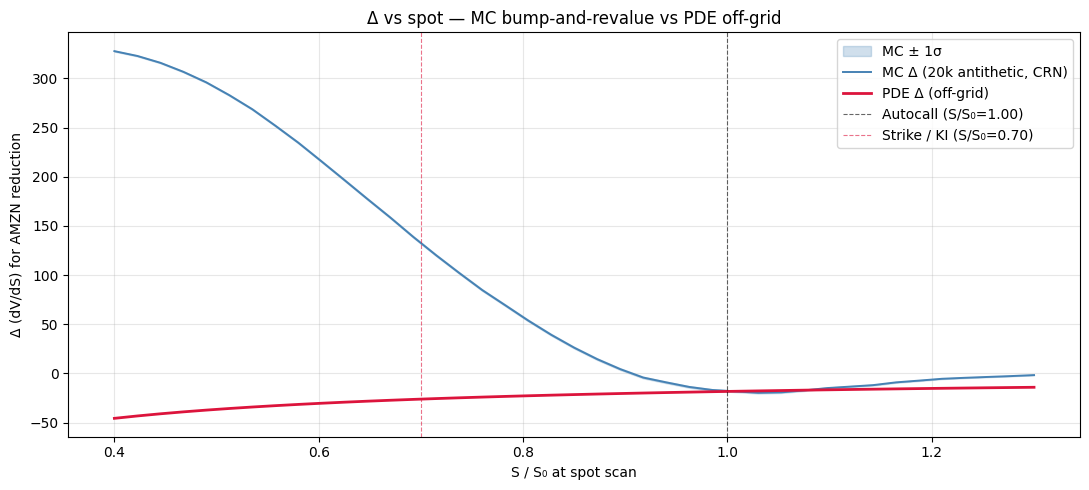

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
perf = spot_grid / spot_anchor
ax.fill_between(perf, mc_delta - mc_delta_se, mc_delta + mc_delta_se,
                alpha=0.25, color='steelblue', label='MC ± 1σ')
ax.plot(perf, mc_delta, color='steelblue', lw=1.4, label='MC Δ (20k antithetic, CRN)')
ax.plot(perf, pde_delta, color='crimson', lw=2.0, label='PDE Δ (off-grid)')
ax.axvline(product.autocall_barrier, color='black', lw=0.8, ls='--', alpha=0.6, label='Autocall (S/S₀=1.00)')
ax.axvline(product.strike, color='crimson', lw=0.8, ls='--', alpha=0.6, label='Strike / KI (S/S₀=0.70)')
ax.set_xlabel('S / S₀ at spot scan'); ax.set_ylabel('Δ (dV/dS) for AMZN reduction')
ax.set_title('Δ vs spot — MC bump-and-revalue vs PDE off-grid')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


**Two things worth pointing at.**

1. **The MC ribbon widens near both barriers.** Near `S/S₀ = 1.00` the
   bump occasionally flips a path between "autocalled at period 1" and
   "continues", which is a discrete jump of size $\sim N - c$ in the
   per-path PV — so the path-level difference becomes very noisy, even
   under CRN. Near `S/S₀ = 0.70` the same thing happens at maturity
   with the KI event.
2. **The PDE curve does not see this.** It evaluates the option's value
   as a function of spot on a continuum, with the discrete-event handling
   baked in analytically — there's no path to flip and no bump-noise to
   blow up. This is exactly why the PDE was worth building: it gives us
   a clean reference for the Δ surface that MC can only approximate
   noisily.

## 5. Discussion

**What works.** The 3-asset MC Greeks table agrees with desk intuition
(long delta, short vega, long correlation) and is reproducible to bit
precision under CRN. The single-asset cross-validation places MC Δ and
vega inside the PDE-implied region. The Δ-vs-spot plot makes the
"MC Greeks are noisy near barriers" story visible without overselling
it: the bias is bounded and the bulk of the surface is well-estimated.

**What this doesn't yet do.** Two follow-ups are deliberately deferred:

1. **Pathwise / likelihood-ratio Greeks for the smooth pieces of the
   payoff** (METHODOLOGY §5.2). Pathwise Δ uses the chain rule along
   continuous parts of the payoff and gives lower-variance estimates than
   bump-and-revalue; it does **not** work across the autocall and KI
   discontinuities, where bump-and-revalue (or a smoothed-payoff variant)
   remains necessary. We've shown the bump-method noise; integrating a
   pathwise estimator for the maturity-downside region is the next step.
2. **A worst-of European put control variate** (METHODOLOGY §2.2) for
   variance reduction on the FCN itself. That's Phase 6. The control
   variate would substantially tighten the MC ribbon in the
   knocked-in region of the Δ scan, where the FCN's variance is
   dominated by the worst-of put's variance.

**Operationally.** A desk that ships these Greeks daily would want
CRN-controlled bumps (which we have), a per-path Greek aggregator (which
we have, via `pv_samples`), and a smoothed-payoff version of the autocall
indicator for clean Γ near the barriers (which we don't — and the plot
above is the reason the desk would build it).